In [2]:
import numpy as np 
from dataloader import open_dataset

In [3]:
foccus_path = '/lustre/storeB/project/fou/hi/foccus/malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res'
result_path_file = 'lr_v2/lr3-5e-04-st200-se42/2024-03-30_24h_18d28_e011_s049990.nc'


In [4]:
ds = open_dataset(f'{foccus_path}/{result_path_file}').dataset

In [5]:
import seaborn as sns 
#extract wished variables 

In [22]:
import matplotlib.pyplot as plt 

In [7]:
temp, salinity, u, v = ds['temperature_0'].isel(time = 1), ds['salinity_0'].isel(time = 1), ds['u_eastward_0'].isel(time = 1), ds['v_northward_0'].isel(time = 1)

In [8]:
temp_r, salinity_r, u_r, v_r = temp.values.ravel(), salinity.values.ravel(), u.values.ravel(), v.values.ravel()
temp_n, salinity_n, u_n, v_n = temp_r[~np.isnan(temp_r)], salinity_r[~np.isnan(salinity_r)], u_r[~np.isnan(u_r)], v_r[~np.isnan(v_r)] 

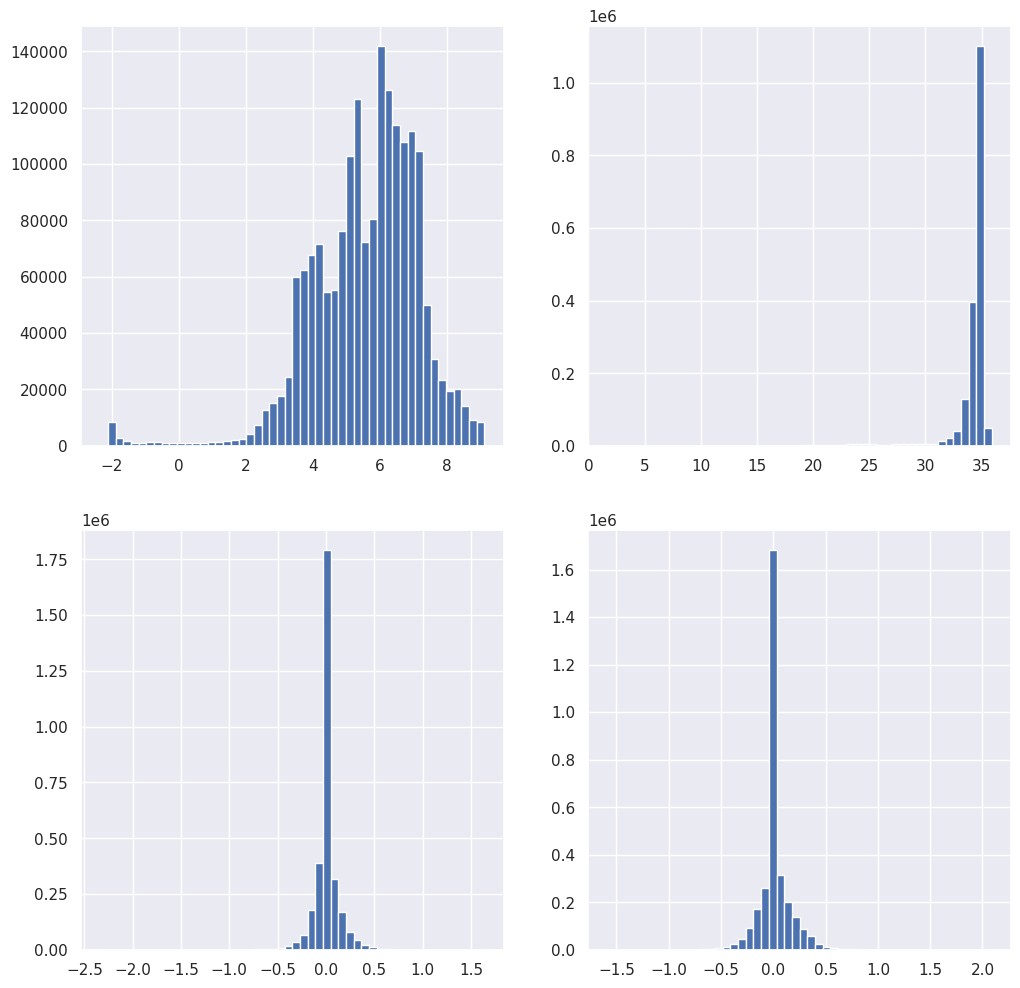

In [13]:
fig, ax = plt.subplots(2,2, figsize = (12,12))
ax[0,0].hist(temp_n, bins = 50)
ax[0,1].hist(salinity_n, bins = 50)
ax[1,0].hist(u_n, bins = 50)
ax[1,1].hist(v_n, bins = 50)
for i in range(0,2):
    for j in range(0,2):
        ax[i,j].grid(True)

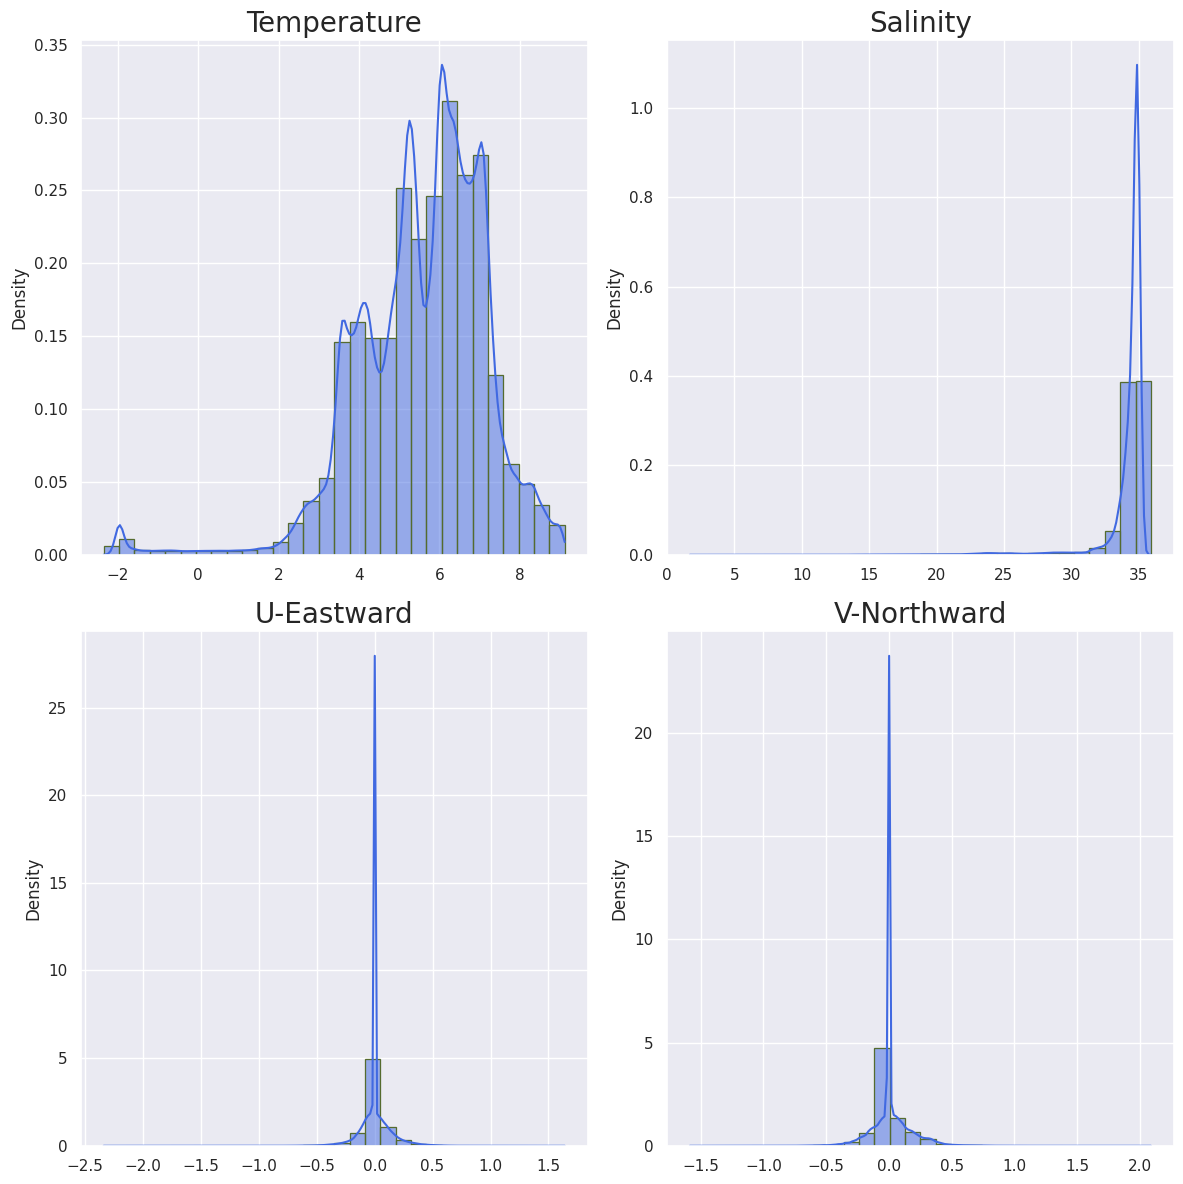

In [30]:
variables = ['temperature_0', 'salinity_0', 'u_eastward_0', 'v_northward_0']
data = {var : ds[var].isel(time = 1).values.ravel() for var in variables}
data = {var : values[~np.isnan(values)] for var, values in data.items()}

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(2,2, figsize = (12,12))
titles = ['Temperature', 'Salinity', 'U-Eastward', 'V-Northward']

for i, (var, values) in enumerate(data.items()):
    row, col = divmod(i,2)
    sns.histplot(values, bins = 30, kde = True, ax = ax[row, col], stat='density', color = 'royalblue', edgecolor = 'darkolivegreen')
    ax[row, col].set_title(titles[i], fontsize = 20)
    #ax[row, col].

plt.tight_layout()
plt.show()